# 31. 창고가 유한하면 얼마나 남나

## Overview

지금까지의 계산에는 **가정 하나가 숨어 있습니다: 창고가 무한하다.**

운영 규칙이 "확신도 0.20 이상인 날은 전부 미룬다"인데, 그러려면 그날 신호가
난 물량을 **전부** 넣을 수 있어야 합니다. 실제로는 창고가 유한하고,
**신호는 여름에 몰립니다** — 8월 11일 실행에서 행동 대상 8품목이 전부
'미룸'이었습니다(9~11월은 반대로 '오늘 판매'가 86~100%).

몰리는 계절에 다 못 넣는다면, **16.18% 라는 창고비 한도는 낙관치**입니다.

## 어떻게 재나

품목별 **물량**은 datago 출하량이 9품목뿐이라 쓸 수 없습니다. 대신
**품목-일(item-day)을 같은 크기의 칸**으로 놓습니다.

| | |
|---|---|
| 칸 1개 | 어떤 품목의 하루치 출하량 |
| 용량 `C` | 동시에 창고에 둘 수 있는 칸 수 |
| 최대 필요량 | 16품목 x 7거래일 = **112칸** (전부 미룰 때) |

**품목마다 출하량이 다른데 같은 칸으로 놓는 게 이 문서의 가장 큰 근사**
입니다. 배추 하루치와 미나리 하루치가 같은 부피는 아닙니다. 그래도
"용량이 조이면 무슨 일이 생기나"의 방향과 크기는 볼 수 있습니다.

## 규칙

용량이 찼을 때 무엇을 포기할지가 핵심입니다.

1. 만기(7거래일)가 된 것을 먼저 뺀다
2. 그날 '미룸' 신호가 난 품목을 **확신도 높은 순**으로 줄 세운다
3. 빈 칸만큼 넣는다
4. **못 넣은 것은 오늘 판다**

확신도 순으로 고르는 이유는 그게 가진 정보를 가장 잘 쓰는 방법이라서
입니다. 다른 규칙(가격 높은 순 등)은 5절에서 따로 봅니다.

## 목차

1. 준비: 예측과 만기일
2. 무한 용량일 때 실제로 몇 칸이 필요한가
3. 용량을 조여가며 재기
4. 언제 조이나: 월별·품목별
5. 고르는 규칙을 바꾸면
6. 정리

## 1. 준비: 예측과 만기일

`model/` 패키지의 워크포워드 예측을 그대로 씁니다. 각 (품목, 날짜)의
**만기일**은 그 품목의 7거래일 뒤 날짜입니다 — 라벨을 만든 방식과 같게
행 기준으로 셉니다.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager

import model as M
from model import config as CFG

warnings.filterwarnings("ignore")
_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

r, GROUPS, FEAT = M.run()
대상 = GROUPS["운영 대상"]
r = r[r.item.isin(대상)].reset_index(drop=True)

# 만기일: 그 품목의 HORIZON 거래일 뒤 날짜
cal = (FEAT[["item", "price_date"]].drop_duplicates()
       .sort_values(["item", "price_date"]).reset_index(drop=True))
cal["exit_date"] = cal.groupby("item").price_date.shift(-CFG.HORIZON)
r = r.merge(cal, on=["item", "price_date"], how="left")

r["미룸신호"] = (r.오를확률 > 0.5) & (r.확신도 >= CFG.THRESHOLD)
print(f"운영 대상 {len(대상)}품목 · 예측 {len(r):,}행")
print(f"기간 {r.price_date.min():%Y-%m-%d} ~ {r.price_date.max():%Y-%m-%d}")
print(f"미룸 신호: {r.미룸신호.sum():,}건 ({r.미룸신호.mean()*100:.1f}%)")
print(f"만기일 없는 행(끝부분): {r.exit_date.isna().sum():,}행 — 시뮬레이션에서 제외")

운영 대상 16품목 · 예측 13,695행
기간 2023-01-02 ~ 2026-07-31
미룸 신호: 2,638건 (19.3%)
만기일 없는 행(끝부분): 112행 — 시뮬레이션에서 제외


## 2. 무한 용량일 때 실제로 몇 칸이 필요한가

용량을 조이기 전에, **지금 규칙이 요구하는 재고량**을 봅니다. 이게
평평하면 용량 제약이 무의미하고, 뾰족하면 그 봉우리가 문제입니다.

In [2]:
sim = r.dropna(subset=["exit_date"]).reset_index(drop=True)
days = np.sort(sim.price_date.unique())

# 무한 용량: 미룸 신호를 전부 넣었을 때의 일별 재고
넣음 = sim[sim.미룸신호]
재고 = pd.Series(0, index=days, dtype=int)
for d, e in zip(넣음.price_date.values, 넣음.exit_date.values):
    재고.loc[(days >= d) & (days < e)] += 1

MAXN = len(대상) * CFG.HORIZON
print(f"이론상 최대 필요량: {len(대상)}품목 x {CFG.HORIZON}거래일 = {MAXN}칸")
print(f"실제 재고  평균 {재고.mean():.1f}칸 · 중앙 {재고.median():.0f}칸 "
      f"· 최대 {재고.max()}칸")
for q in (0.5, 0.75, 0.9, 0.95, 0.99):
    print(f"  {q*100:.0f} 분위: {재고.quantile(q):.0f}칸")

이론상 최대 필요량: 16품목 x 7거래일 = 112칸
실제 재고  평균 20.5칸 · 중앙 7칸 · 최대 98칸
  50 분위: 7칸
  75 분위: 35칸
  90 분위: 66칸
  95 분위: 80칸
  99 분위: 95칸


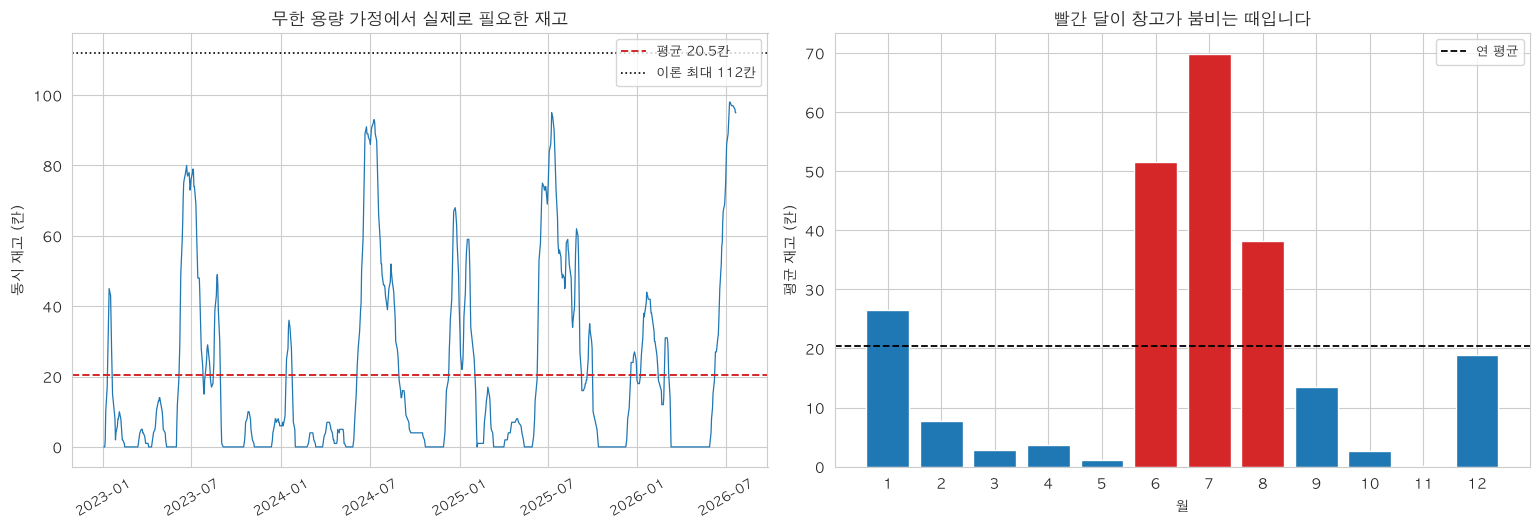

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.4))

ax = axes[0]
ax.plot(재고.index, 재고.values, lw=0.9, color="tab:blue")
ax.axhline(재고.mean(), color="tab:red", ls="--", lw=1.4,
           label=f"평균 {재고.mean():.1f}칸")
ax.axhline(MAXN, color="black", ls=":", lw=1.2, label=f"이론 최대 {MAXN}칸")
ax.set_ylabel("동시 재고 (칸)")
ax.set_title("무한 용량 가정에서 실제로 필요한 재고", fontsize=12)
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=30, labelsize=9)

ax = axes[1]
월 = pd.Series(재고.values, index=pd.DatetimeIndex(재고.index)).groupby(
    lambda d: d.month).mean()
cols = ["tab:red" if v >= 월.quantile(0.75) else "tab:blue" for v in 월]
ax.bar(월.index, 월.values, color=cols)
ax.axhline(재고.mean(), color="black", ls="--", lw=1.3, label="연 평균")
ax.set_xticks(range(1, 13))
ax.set_xlabel("월")
ax.set_ylabel("평균 재고 (칸)")
ax.set_title("빨간 달이 창고가 붐비는 때입니다", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3. 용량을 조여가며 재기

이제 용량 `C` 를 정하고 규칙대로 돌립니다.

**못 넣은 것은 오늘 팝니다.** 창고가 없으면 미루지 못하니까요. 그래서
용량이 작아질수록 '더 받은 돈'은 줄어드는데, **창고비 한도는 오히려
오를 수 있습니다** — 확신도 높은 것만 골라 넣게 되기 때문입니다.

In [4]:
def 시뮬(cap, key="확신도"):
    # 용량 cap 으로 하루씩 돌린다. 넣은 행에 True 를 표시해 돌려준다.
    d = sim.sort_values(["price_date", key], ascending=[True, False])
    보유 = []                       # exit_date 목록
    넣음 = np.zeros(len(d), dtype=bool)
    pos = {v: i for i, v in enumerate(d.index)}
    for day, g in d.groupby("price_date", sort=True):
        보유 = [e for e in 보유 if e > day]      # 만기 배출
        여유 = cap - len(보유)
        if 여유 <= 0:
            continue
        후보 = g[g.미룸신호]
        for idx, e in zip(후보.index[:여유], 후보.exit_date.values[:여유]):
            넣음[pos[idx]] = True
            보유.append(e)
    out = d.copy()
    out["넣음"] = 넣음
    return out.sort_index()


def 성적(o, n_items):
    # 용량 제약이 반영된 성적. score() 와 달리 '넣음' 을 직접 받는다.
    실현 = np.where(o.넣음, o.미래가격.values, o.price_kg_avg.values)
    더받은돈 = (실현.mean() / o.price_kg_avg.mean() - 1) * 100
    비율 = o.넣음.mean()
    기간 = (o.price_date.max() - o.price_date.min()).days / 365.25
    return {
        "창고행 %": 비율 * 100,
        "신호 대비 실행률 %": o.넣음.sum() / o.미룸신호.sum() * 100,
        "넣은 날 적중률 %": o[o.넣음].방향맞음.mean() * 100 if o.넣음.any() else np.nan,
        "더 받은 돈 %": 더받은돈,
        "창고비 한도 %": 더받은돈 / 비율 if 비율 > 0 else np.nan,
        "품목당 연 창고행": o.넣음.sum() / 기간 / n_items,
    }


CAPS = [5, 10, 15, 20, 30, 40, 60, MAXN]
rows = {}
for c in CAPS:
    rows[c] = 성적(시뮬(c), len(대상))
용량표 = pd.DataFrame(rows).T
용량표.index.name = "용량(칸)"
display(용량표.round(2))
print(f"용량 {MAXN} 은 사실상 무제한입니다(이론 최대).")

,창고행 %,신호 대비 실행률 %,넣은 날 적중률 %,더 받은 돈 %,창고비 한도 %,품목당 연 창고행
용량(칸),,,,,,
5,2.53,13.41,74.93,0.43,17.12,6.04
10,4.61,24.47,75.40,0.78,16.97,11.02
15,6.46,34.28,75.60,1.09,16.82,15.44
20,8.13,43.16,75.82,1.37,16.91,19.43
30,11.12,59.03,75.89,1.77,15.94,26.58
40,13.43,71.31,75.27,2.01,15.00,32.10
60,16.57,88.00,74.72,2.40,14.48,39.62
112,18.83,100.00,74.67,2.60,13.83,45.02


용량 112 은 사실상 무제한입니다(이론 최대).


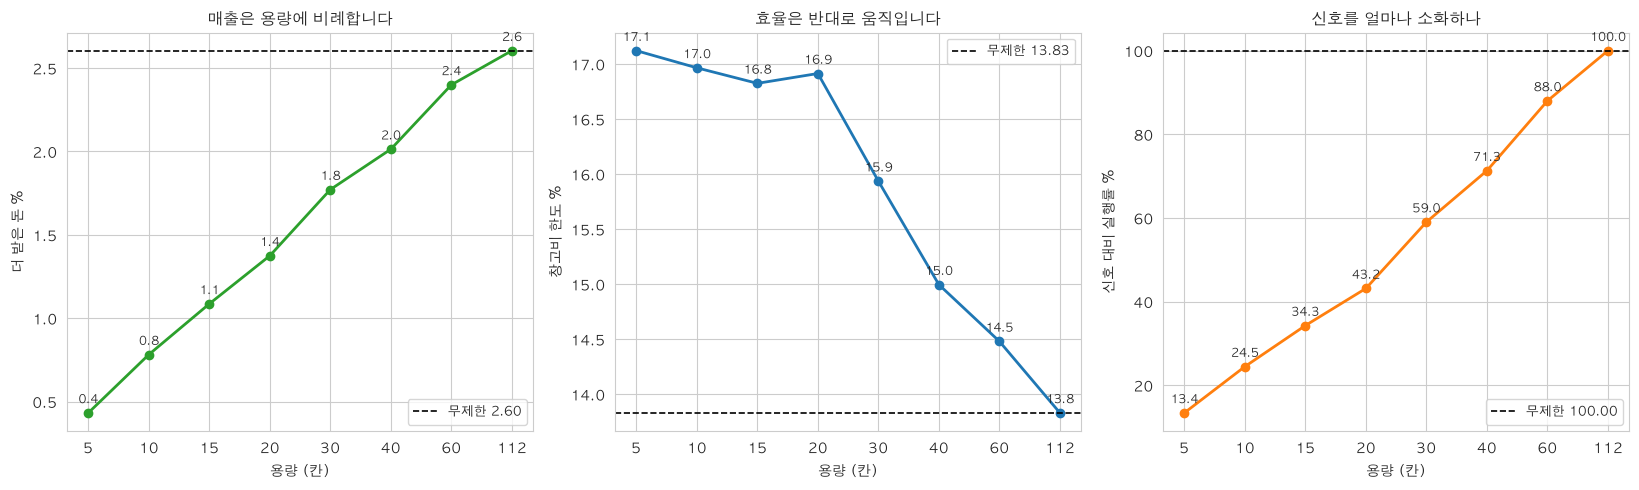

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))
x = 용량표.index.astype(str)

for ax, col, 색, ttl in (
        (axes[0], "더 받은 돈 %", "tab:green", "매출은 용량에 비례합니다"),
        (axes[1], "창고비 한도 %", "tab:blue", "효율은 반대로 움직입니다"),
        (axes[2], "신호 대비 실행률 %", "tab:orange", "신호를 얼마나 소화하나")):
    ax.plot(x, 용량표[col], "o-", color=색, lw=2, ms=6)
    base = 용량표[col].iloc[-1]
    ax.axhline(base, color="black", ls="--", lw=1.2,
               label=f"무제한 {base:.2f}")
    for xi, v in zip(x, 용량표[col]):
        ax.annotate(f"{v:.1f}", (xi, v), textcoords="offset points",
                    xytext=(0, 7), ha="center", fontsize=8.5)
    ax.set_xlabel("용량 (칸)")
    ax.set_ylabel(col)
    ax.set_title(ttl, fontsize=11.5)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. 언제 조이나: 월별·품목별

용량이 조일 때 **무엇이 밀려나는지**가 실무 판단에 직결됩니다.

In [6]:
기준용량 = 20
o = 시뮬(기준용량)
o["월"] = o.price_date.dt.month

월별 = o[o.미룸신호].groupby("월").agg(
    신호=("미룸신호", "size"), 실행=("넣음", "sum"))
월별["실행률 %"] = 월별.실행 / 월별.신호 * 100
display(월별.round(1))

품목별 = o[o.미룸신호].groupby("item").agg(
    신호=("미룸신호", "size"), 실행=("넣음", "sum"))
품목별["실행률 %"] = 품목별.실행 / 품목별.신호 * 100
품목별["평균 확신도"] = o[o.미룸신호].groupby("item").확신도.mean()
display(품목별.sort_values("실행률 %").round(3))
print(f"용량 {기준용량}칸 기준입니다. 실행률이 낮은 품목이 밀려난 쪽입니다.")

,신호,실행,실행률 %
월,,,
1,311,162,52.1
2,86,69,80.2
3,9,9,100.0
4,52,52,100.0
5,8,8,100.0
6,715,234,32.7
7,776,230,29.6
8,330,159,48.2
9,76,59,77.6


,신호,실행,실행률 %,평균 확신도
item,,,,
고구마,10,2,20.000,0.219
알배기배추,141,37,26.241,0.260
감자,121,32,26.446,0.263
양파,110,31,28.182,0.272
깻잎,182,59,32.418,0.264
무,157,59,37.580,0.293
파,200,78,39.000,0.272
얼갈이배추,158,62,39.241,0.302
양배추,139,57,41.007,0.304


용량 20칸 기준입니다. 실행률이 낮은 품목이 밀려난 쪽입니다.


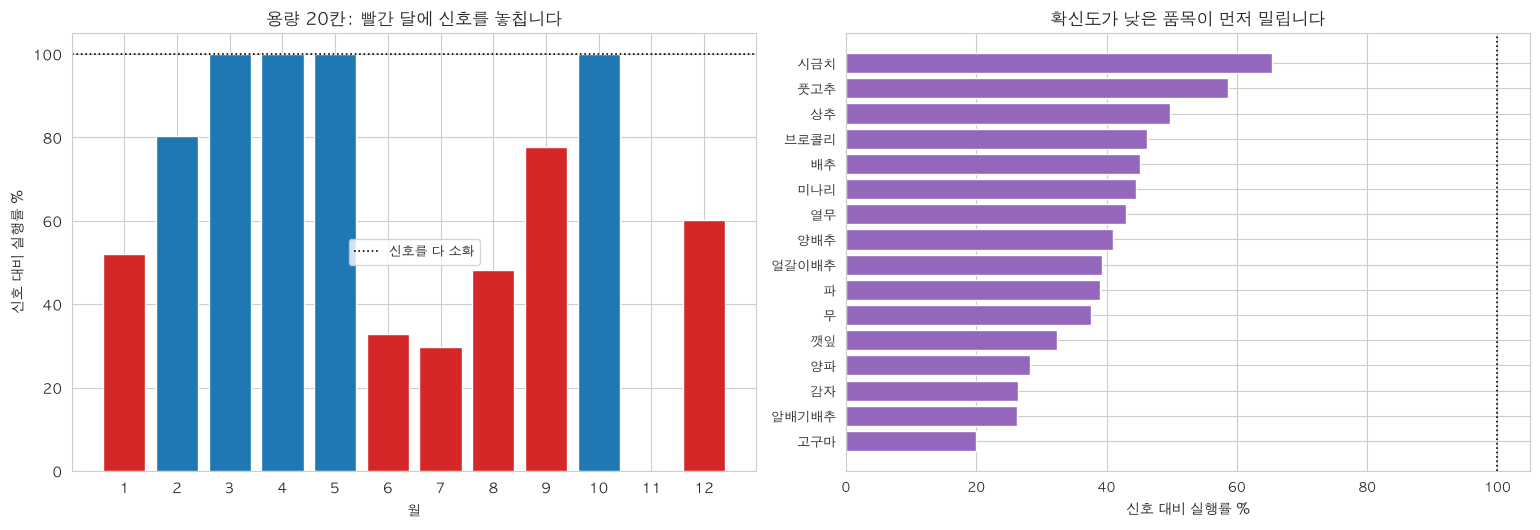

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.4))

ax = axes[0]
cols = ["tab:red" if v < 80 else "tab:blue" for v in 월별["실행률 %"]]
ax.bar(월별.index, 월별["실행률 %"], color=cols)
ax.axhline(100, color="black", ls=":", lw=1.2, label="신호를 다 소화")
ax.set_xticks(range(1, 13))
ax.set_xlabel("월")
ax.set_ylabel("신호 대비 실행률 %")
ax.set_title(f"용량 {기준용량}칸: 빨간 달에 신호를 놓칩니다", fontsize=12)
ax.legend(fontsize=9)

ax = axes[1]
s = 품목별.sort_values("실행률 %")
ax.barh(s.index, s["실행률 %"], color="tab:purple")
ax.axvline(100, color="black", ls=":", lw=1.2)
ax.set_xlabel("신호 대비 실행률 %")
ax.set_title("확신도가 낮은 품목이 먼저 밀립니다", fontsize=12)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

## 5. 고르는 규칙을 바꾸면

용량이 찼을 때 확신도 순으로 골랐습니다. 다른 기준이 나을 수 있습니다.

| 규칙 | 노리는 것 |
|---|---|
| 확신도 순 | 가진 정보를 가장 잘 쓴다 |
| 가격 높은 순 | 같은 칸이면 비싼 물건이 이득이 크다 |
| 저장일수 긴 순 | 오래 버티는 것부터 |

**비싼 물건을 넣는 게 유리해 보이지만**, 여기서는 칸을 물량이 아니라
품목-일로 놓았으므로 '비싸다'가 곧 '이득이 크다'는 아닙니다. 실제로
재봅니다.

In [8]:
sim["저장일수"] = sim.item.map(CFG.STORAGE_DAYS)
rows = {}
for name, key in (("확신도 순", "확신도"), ("가격 높은 순", "price_kg_avg"),
                  ("저장일수 긴 순", "저장일수")):
    rows[name] = 성적(시뮬(기준용량, key=key), len(대상))
규칙표 = pd.DataFrame(rows).T
display(규칙표.round(2))
print(f"용량 {기준용량}칸 · 같은 예측, 고르는 순서만 다릅니다.")

,창고행 %,신호 대비 실행률 %,넣은 날 적중률 %,더 받은 돈 %,창고비 한도 %,품목당 연 창고행
확신도 순,8.13,43.16,75.82,1.37,16.91,19.43
가격 높은 순,8.13,43.16,73.73,1.61,19.78,19.43
저장일수 긴 순,8.13,43.16,71.01,0.83,10.19,19.43


용량 20칸 · 같은 예측, 고르는 순서만 다릅니다.


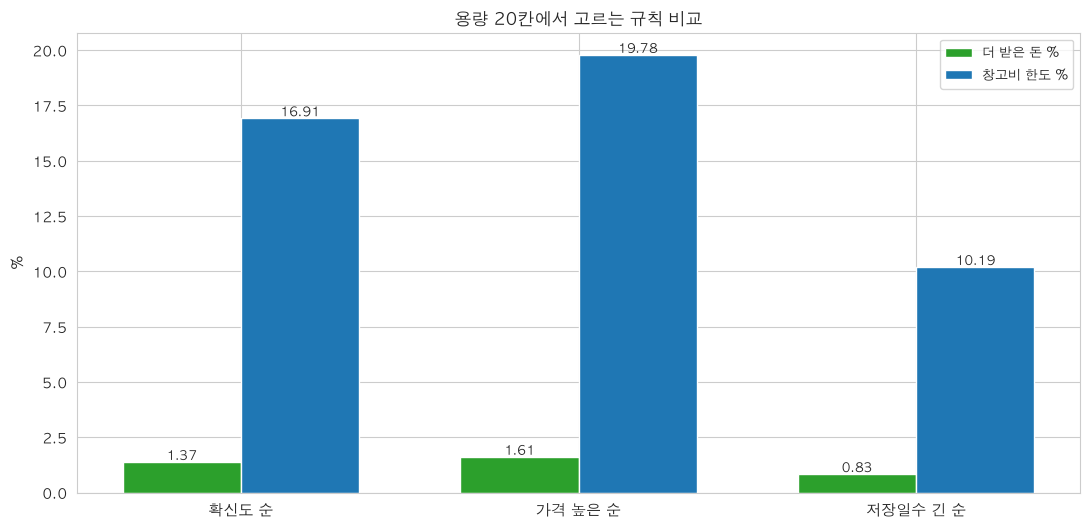

In [9]:
fig, ax = plt.subplots(figsize=(11, 5.4))
w = 0.35
x = np.arange(len(규칙표))
ax.bar(x - w/2, 규칙표["더 받은 돈 %"], width=w, color="tab:green",
       label="더 받은 돈 %")
ax.bar(x + w/2, 규칙표["창고비 한도 %"], width=w, color="tab:blue",
       label="창고비 한도 %")
for i, (a, b) in enumerate(zip(규칙표["더 받은 돈 %"], 규칙표["창고비 한도 %"])):
    ax.text(i - w/2, a + 0.1, f"{a:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, b + 0.1, f"{b:.2f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(규칙표.index, fontsize=10.5)
ax.set_ylabel("%")
ax.set_title(f"용량 {기준용량}칸에서 고르는 규칙 비교", fontsize=12)
ax.legend(fontsize=9.5)
plt.tight_layout()
plt.show()

## 6. 정리

### 한 줄 요약

**창고비 한도는 낙관치가 아니었습니다 — 오히려 보수적이었습니다.** 용량을
조이면 한도는 13.83% → **17.12%로 오릅니다.** 대신 **버는 절대액이
6분의 1로 줍니다**(2.60% → 0.43%).

즉 **용량 제약은 전략을 깨는 게 아니라 작게 만듭니다.**

### 용량별 성적

| 용량(칸) | 신호 소화율 | 더 받은 돈 | 창고비 한도 |
|---|---|---|---|
| 5 | 13.4% | 0.43% | **17.12%** |
| 10 | 24.5% | 0.78% | 16.97% |
| **20** (평균 수준) | **43.2%** | **1.37%** | **16.91%** |
| 40 | 71.3% | 2.01% | 15.00% |
| 60 | 88.0% | 2.40% | 14.48% |
| 112 (무제한) | 100% | **2.60%** | 13.83% |

**두 지표가 반대로 움직입니다.** 칸이 적으면 확신도 높은 것만 넣게 되어
효율(한도)이 오르고, 대신 기회를 많이 놓쳐 매출(더 받은 돈)이 줍니다.

### 평균에 맞춰 지으면 절반밖에 못 법니다

재고 요구량이 **극단적으로 뾰족합니다.**

| | 칸 |
|---|---|
| 중앙값 | **7** |
| 평균 | 20.5 |
| 75 분위 | 35 |
| 95 분위 | 80 |
| 최대 | 98 |

**중앙값 7칸인데 최대 98칸입니다.** 절반의 날은 거의 비어 있고, 몰리는
날엔 이론 최대(112칸)에 육박합니다.

그래서 평균(20칸)에 맞춰 지으면 신호의 **43%밖에 소화 못 하고** 무제한
대비 **53%만 법니다**(1.37% / 2.60%). 88%를 벌려면 60칸 — **평균의 3배**가
필요합니다.

**창고 투자 판단에 직접 쓰이는 숫자입니다.** 29번의 역산(1평 시공 450만)에
대입하면, 60칸을 짓는 비용이 평균 용량의 3배가 됩니다. 그래도 29번 결론은
안 뒤집힙니다 — 한도가 14.48%로 여전히 역산 창고비(0.5~2.9%)의 5배 위입니다.

### 여름에 못 넣습니다 (짐작대로)

용량 20칸에서 월별 신호 소화율입니다.

| 월 | 소화율 |
|---|---|
| **6월** | **32.7%** (신호 715건) |
| **7월** | **29.6%** (신호 776건) |
| 8월 | 48.2% |
| 1월 | 52.1% |
| 3·4·5·10월 | **100%** |

**6~7월에 신호의 70%를 놓칩니다.** 신호가 몰리는 달이 곧 못 넣는 달입니다.
반대로 봄·가을은 신호 자체가 적어(3월 9건, 5월 8건) 다 소화합니다.

**설비를 여름 기준으로 잡아야 한다**는 29번의 지적이 여기서 정량화됐습니다.

### 밀려나는 품목

용량 20칸에서 실행률이 낮은 쪽입니다.

| 품목 | 실행률 | 평균 확신도 |
|---|---|---|
| 고구마 | 20.0% | 0.219 |
| 알배기배추 | 26.2% | 0.260 |
| 감자 | 26.4% | 0.263 |
| … | | |
| 풋고추 | 58.7% | 0.286 |
| 시금치 | **65.4%** | 0.300 |

**확신도가 낮은 품목이 먼저 밀립니다.** 규칙이 의도한 대로 동작합니다.
다만 고구마는 신호 자체가 10건뿐이라 비율이 불안정합니다.

### 예상이 틀린 곳: 가격 높은 순이 낫습니다

용량 20칸에서 고르는 순서만 바꿔봤습니다.

| 규칙 | 넣은 날 적중률 | 더 받은 돈 | 창고비 한도 |
|---|---|---|---|
| 확신도 순 | **75.82%** | 1.37% | 16.91% |
| **가격 높은 순** | 73.73% | **1.61%** | **19.78%** |
| 저장일수 긴 순 | 71.01% | 0.83% | 10.19% |

**본문에서 "비싸다가 곧 이득이 크다는 아니다"라고 썼는데 틀렸습니다.**
가격 순이 적중률은 2%p 낮은데 돈은 **17% 더 벌고** 한도는 **2.87%p 높습니다.**

맞히는 횟수보다 **맞혔을 때의 크기**가 중요하다는 뜻입니다. 확신도는
"오를 확률"만 보고 "얼마나 오를지"는 안 봅니다.

⚠️ **다만 이 결과가 칸 가정에 가장 민감합니다.** 칸을 품목-일로 놓았기
때문에 "비싼 품목 = 칸당 가치 큼"이 성립했습니다. 실제로는 품목마다
하루 출하량이 달라, 비싼 품목이 물량은 적을 수 있습니다. **물량 데이터
없이 이 규칙을 채택하면 안 됩니다.**

### 한계

- **칸 크기를 같다고 놓았습니다.** 이 문서의 가장 큰 근사입니다. 배추
  하루치와 미나리 하루치는 부피가 다릅니다. datago 출하량이 9품목뿐이라
  물량 정규화를 못 했습니다.
- **용량이 연중 고정입니다.** 실제로는 임차로 늘리거나 다른 용도와
  나눠 쓸 수 있습니다.
- **못 넣으면 즉시 판다고 놓았습니다.** 하루 뒤에 다시 시도하는 규칙이면
  결과가 달라집니다.
- **감모·등급 하락이 여전히 안 들어갔습니다**(28·29번과 같은 한계).
- 창고행 판단은 워크포워드 예측이라 정직하지만, **용량 규칙 자체는
  사후에 정한 것**입니다. 여러 규칙을 비교한 5절은 그만큼 낙관적입니다.

### 다음

1. **물량을 붙이면 이 문서가 정확해집니다.** datago 출하량을 나머지
   10품목까지 늘리면 칸을 kg 기준으로 정규화할 수 있습니다. 3절
   '신규 품목 출하량 매핑'과 목적이 겹칩니다.
2. **가격 순 규칙은 물량 확보 전까지 보류합니다.** 유망하지만 칸 가정에
   기대고 있습니다.
3. **29번 결론은 유지됩니다.** 용량을 조여도 창고비 한도가 14~17%라
   역산 창고비(0.5~2.9%)의 5배 위입니다.